### Definition & import

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append(r'C:\Users\fetschlab\Documents\Python\Neural-Pipeline')
from neuralpipeline.offline_processing_openephys.MemSaccPlot import NeuralDataLoader
########### Zarya Trial Settings #############

angles = np.zeros(20)
eccs = np.zeros(20)

eccs[[0, 2, 4, 6]] = 5
eccs[[1, 3, 5, 7, 10, 13, 16, 19]] = 10
eccs[[8, 11, 14, 17]] = 3.5
eccs[[9, 12]] = 6.72
eccs[[15, 18]] = 5.83

angles[[0, 1]] = 0
angles[[2, 3]] = 90
angles[[4, 5]] = 180
angles[[6, 7]] = 270
angles[[8, 9, 10]] = 42
angles[[11, 12, 13]] = 138
angles[[14, 15, 16]] = 211
angles[[17, 18, 19]] = 329   

########### Plot Settings #############

align_info_list = [{'event': 'STIMON', 'pre': -0.1, 'post': 0.1}, 
                   { 'event': 'STIMON', 'pre': 0.1, 'post': 0.5},
                   { 'event': 'SACC', 'pre': -0.5, 'post': 0.1}]

###### variable changed by blocks #############
base_dir = r"C:\Users\fetschlab\Documents\Open Ephys\2025-07-24_13-46-22\Record Node 111\experiment2\recording2"
electrode_id = 3



### Load data

In [31]:
data = NeuralDataLoader(base_dir, electrode_id)
print("\n--- Data Loaded ---")
event_data = data.parse_ttl_events()


Selected base directory: C:\Users\fetschlab\Documents\Open Ephys\2025-07-24_13-46-22\Record Node 111\experiment2\recording2
C:\Users\fetschlab\Documents\Open Ephys\2025-07-24_13-46-22\Record Node 111\experiment2\recording2\spikes\Spike_Detector-110.ProbeA-AP\Electrode 3
Loading spikes from Electrode 3...
Loading TTL data...
Parsing probe configuration...
Channel positions loaded as matrix.

--- Data Loaded ---

Parsed 128 trials, 120 good trials.


### Plot firing rate

Total firing: 9.584912669037752


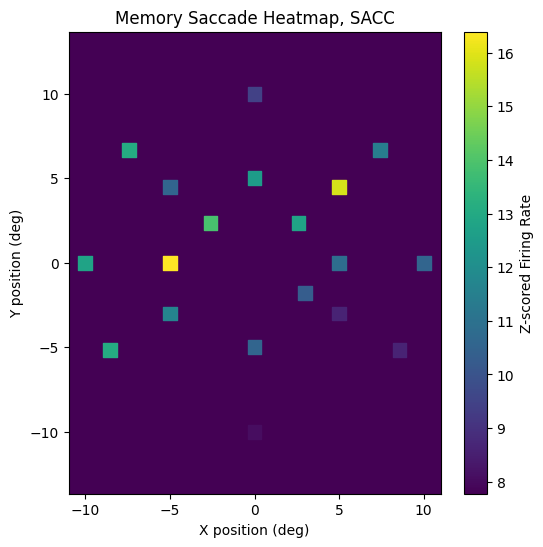

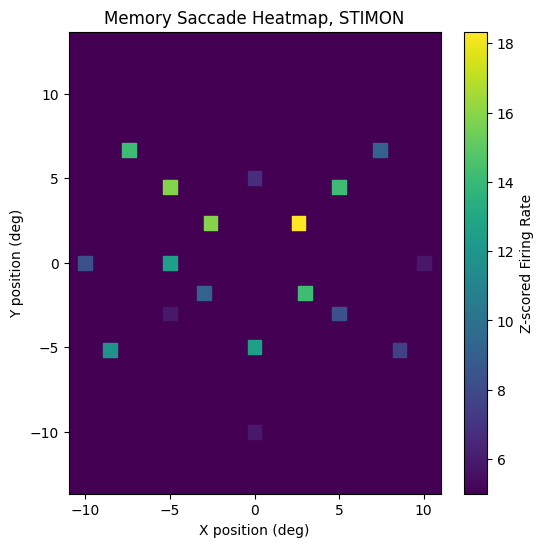

In [32]:

channel = 380
if electrode_id is None: 
    data.get_spike_times(channel, threshold=-65)

total_firing = len(data.spike_times) / (data.ttl_timestamps[-1] - data.ttl_timestamps[0])
print(r"Total firing:", total_firing)
if 1 <= total_firing:
    for align_info in align_info_list:
        try:
            avg_firing_rates = data.avg_firing_rate(align_info)
            data.plot_avg_firing_rate_heatmap(align_info, avg_firing_rates, eccs, angles)
        except IndexError:
            print(f"No spikes detected for event {align_info['event']}. Skipping.")

